In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the generated dataset
df = pd.read_csv("seismic_dataset.csv")

# Diagnostic 1: Check dataframe dimensionality
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Diagnostic 2: Check data types and verify missing value counts
print("\n--- Structural Information ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

Dataset Shape: 100000 rows, 8 columns

--- Structural Information ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Sensor_ID         100000 non-null  str    
 1   X                 100000 non-null  float64
 2   Y                 100000 non-null  float64
 3   Z_Depth           100000 non-null  float64
 4   Dom_Freq_Hz       100000 non-null  float64
 5   Max_Amp           100000 non-null  float64
 6   Spectral_Entropy  100000 non-null  float64
 7   Target_Lithology  100000 non-null  str    
dtypes: float64(6), str(2)
memory usage: 7.8 MB
None

--- Missing Values Count ---
Sensor_ID           0
X                   0
Y                   0
Z_Depth             0
Dom_Freq_Hz         0
Max_Amp             0
Spectral_Entropy    0
Target_Lithology    0
dtype: int64


In [3]:
# Profile 1: Statistical distribution summary for continuous numeric values
print("\n--- Descriptive Statistics ---")
print(df.describe().T)

# Profile 2: Target variable class distribution
print("\n--- Target Class Balance ---")
class_counts = df['Target_Lithology'].value_counts()
class_percentages = df['Target_Lithology'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percentages})
print(balance_df)


--- Descriptive Statistics ---
                     count          mean         std           min  \
X                 100000.0  5.424995e+05  288.499151  5.420000e+05   
Y                 100000.0  4.320499e+06  289.160563  4.320000e+06   
Z_Depth           100000.0  2.003642e+03  577.959562  1.000050e+03   
Dom_Freq_Hz       100000.0  4.486824e+01   29.762507  0.000000e+00   
Max_Amp           100000.0  2.496034e+02   64.658429  1.038700e+02   
Spectral_Entropy  100000.0  6.743877e+00    0.012333  6.706800e+00   

                           25%          50%           75%           max  
X                 5.422484e+05   542498.900  5.427494e+05  5.430000e+05  
Y                 4.320247e+06  4320499.405  4.320750e+06  4.321000e+06  
Z_Depth           1.503517e+03     2004.590  2.505633e+03  2.999940e+03  
Dom_Freq_Hz       1.950000e+01       25.000  7.900000e+01  4.980000e+02  
Max_Amp           1.788400e+02      270.260  3.027325e+02  3.913400e+02  
Spectral_Entropy  6.734400e+00   

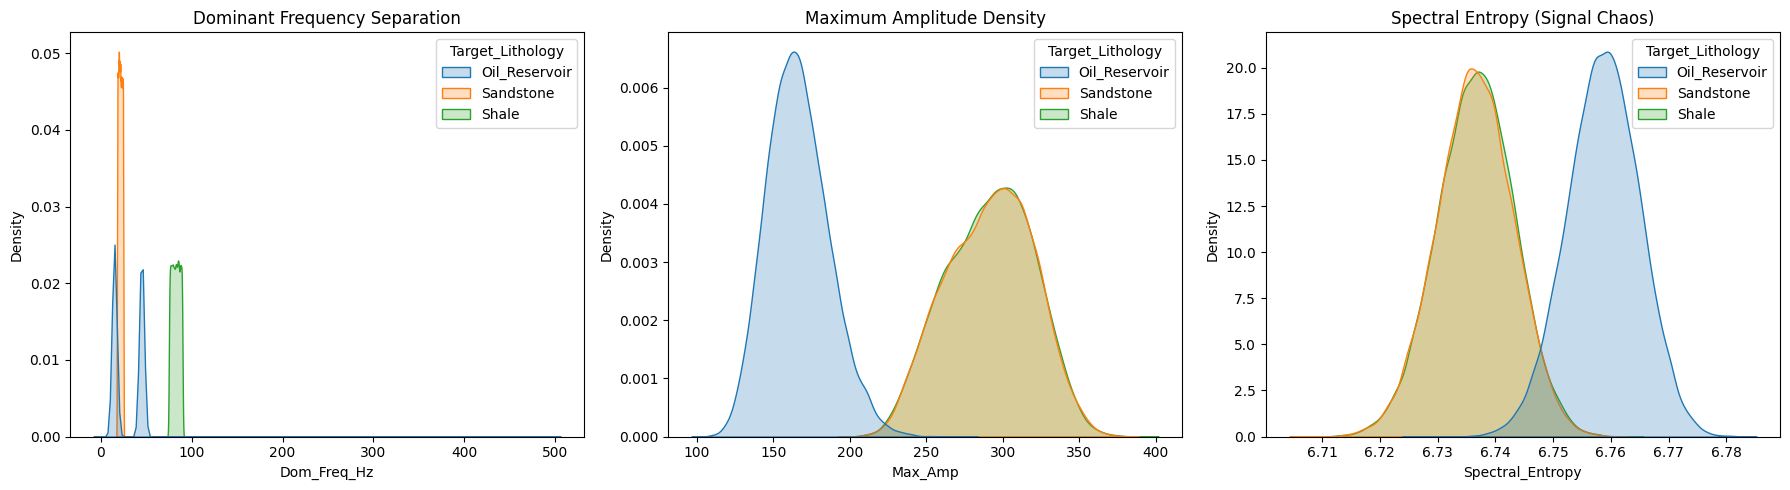

In [4]:
# Set up a multi-panel distribution canvas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Dominant Frequency Distribution grouped by Rock Class
sns.kdeplot(data=df, x='Dom_Freq_Hz', hue='Target_Lithology', fill=True, ax=axes[0])
axes[0].set_title('Dominant Frequency Separation')

# Plot 2: Maximum Amplitude Distribution grouped by Rock Class
sns.kdeplot(data=df, x='Max_Amp', hue='Target_Lithology', fill=True, ax=axes[1])
axes[1].set_title('Maximum Amplitude Density')

# Plot 3: Spectral Entropy Distribution grouped by Rock Class
sns.kdeplot(data=df, x='Spectral_Entropy', hue='Target_Lithology', fill=True, ax=axes[2])
axes[2].set_title('Spectral Entropy (Signal Chaos)')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Isolate features and target vectors
X_spatial = df[['X', 'Y', 'Z_Depth']]
X_dsp = df[['Dom_Freq_Hz', 'Max_Amp', 'Spectral_Entropy']]
y = df['Target_Lithology']

# Execute an 80/20 train-test split stratified on target labels
X_train_sp, X_test_sp, X_train_dsp, X_test_dsp, y_train, y_test = train_test_split(
    X_spatial, X_dsp, y, test_size=0.2, random_state=42, stratify=y
)

# Instantiate and apply scaling transformations
scaler_spatial = StandardScaler()
X_train_sp_scaled = scaler_spatial.fit_transform(X_train_sp)
X_test_sp_scaled = scaler_spatial.transform(X_test_sp)

scaler_dsp = StandardScaler()
X_train_dsp_scaled = scaler_dsp.fit_transform(X_train_dsp)
X_test_dsp_scaled = scaler_dsp.transform(X_test_dsp)

print(f"Training shapes: Spatial={X_train_sp_scaled.shape}, DSP={X_train_dsp_scaled.shape}")
print(f"Testing shapes: Spatial={X_test_sp_scaled.shape}, DSP={X_test_dsp_scaled.shape}")

Training shapes: Spatial=(80000, 3), DSP=(80000, 3)
Testing shapes: Spatial=(20000, 3), DSP=(20000, 3)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the KNN Classifier across the 3D grid
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_sp_scaled, y_train)

# Evaluate predictions on the test holdout set
knn_predictions = knn_model.predict(X_test_sp_scaled)

print("=== KNN Spatial Stratification Report ===")
print(classification_report(y_test, knn_predictions))

=== KNN Spatial Stratification Report ===
               precision    recall  f1-score   support

Oil_Reservoir       0.33      0.45      0.38      6670
    Sandstone       0.33      0.33      0.33      6641
        Shale       0.34      0.21      0.26      6689

     accuracy                           0.33     20000
    macro avg       0.33      0.33      0.32     20000
 weighted avg       0.33      0.33      0.32     20000



In [8]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import classification_report

# Train Logistic Regression model using the LBFGS optimization solver
# (Multinomial classification is now handled automatically by scikit-learn)
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000)
lr_model.fit(X_train_dsp_scaled, y_train)

# Predict classifications on the test holdout set
lr_predictions = lr_model.predict(X_test_dsp_scaled)

print("=== Logistic Regression DSP Classification Report ===")
print(classification_report(y_test, lr_predictions))

# Inspect learned physical weights
coef_df = pd.DataFrame(lr_model.coef_, columns=['Dom_Freq_Hz', 'Max_Amp', 'Spectral_Entropy'], index=lr_model.classes_)
print("\n=== Learned Model Coefficients ===")
print(coef_df)

=== Logistic Regression DSP Classification Report ===
               precision    recall  f1-score   support

Oil_Reservoir       1.00      1.00      1.00      6670
    Sandstone       1.00      1.00      1.00      6641
        Shale       1.00      1.00      1.00      6689

     accuracy                           1.00     20000
    macro avg       1.00      1.00      1.00     20000
 weighted avg       1.00      1.00      1.00     20000


=== Learned Model Coefficients ===
               Dom_Freq_Hz   Max_Amp  Spectral_Entropy
Oil_Reservoir     1.849203 -9.883243          3.598619
Sandstone        -5.407475  6.549110         -2.641025
Shale             3.558272  3.334133         -0.957595
